===== ACC102 Financial Analysis Result =====
Data Period: 2020-01-01 to 2025-12-31
Total Observations: 31352

----- Annual Average ROE -----
year
2020    0.339027
2021    3.118898
2022    3.893593
2023    3.444678
2024    3.463243
2025    3.778842
Name: roe, dtype: float64

----- Top 10 Companies by ROE -----
conm
STAR FASHION CULTR HLDNG LTD    49.983803
CRYO-CELL INTERNATIONAL INC     49.808795
MURPHY USA INC                  49.205569
FUNCTIONAL BRANDS INC           49.188838
EMPRO GROUP INC                 49.181401
TEL-INSTRUMENT ELECTRONICS      48.997135
LILLY (ELI) & CO                48.648799
MOODY'S CORP                    48.432791
FARFETCH LIMITED                48.019283
TOP 10 SPLIT TRUST              47.601810
Name: roe, dtype: float64


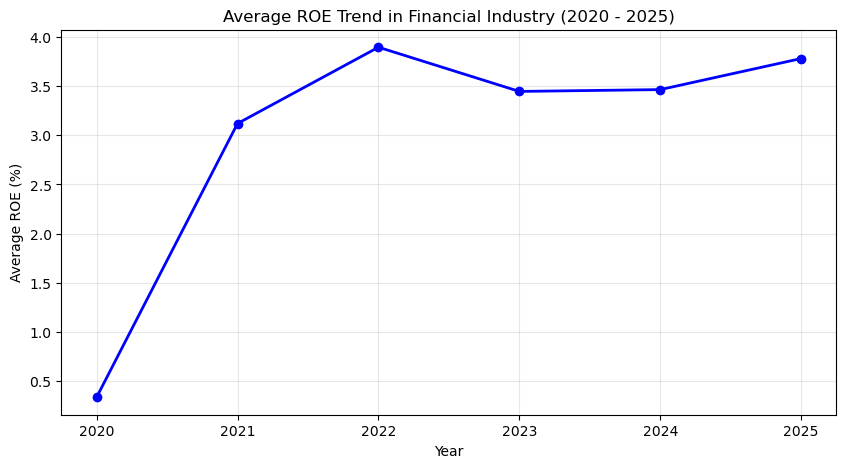

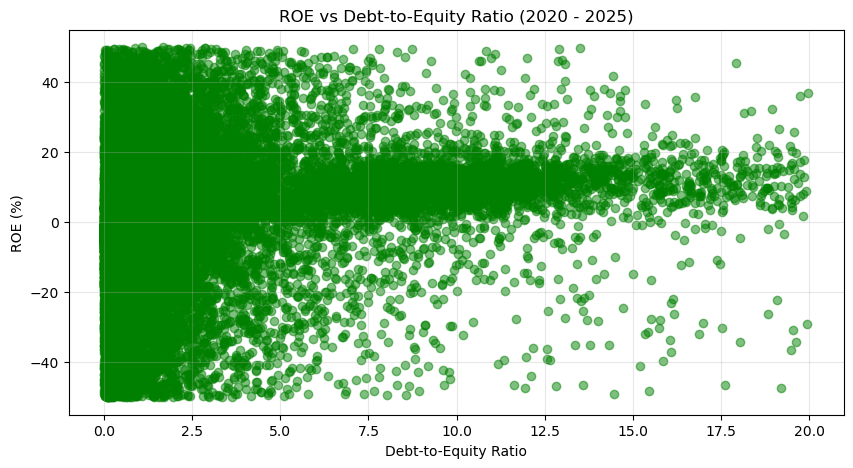

In [1]:
# ==============================================
# ACC102 Mini Assignment: Financial Analysis
# Data Period: January 2020 - December 2025
# Author: Your Name
# ==============================================

# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------
# Step 1: Load and filter data
# ----------------------
# Read raw financial data from data folder
df = pd.read_csv("data/financial_data_2020_2025.csv")

# Convert date column to standard datetime format
df["datadate"] = pd.to_datetime(df["datadate"])

# Strictly filter data range: 2020-01-01 to 2025-12-31
start_date = pd.to_datetime("2020-01-01")
end_date = pd.to_datetime("2025-12-31")
df = df[(df["datadate"] >= start_date) & (df["datadate"] <= end_date)]

# Extract year for annual analysis
df["year"] = df["datadate"].dt.year

# ----------------------
# Step 2: Calculate financial ratios
# ----------------------
# Return on Equity (ROE)
df["roe"] = (df["ni"] / df["ceq"]) * 100

# Debt-to-Equity Ratio
df["de_ratio"] = df["lt"] / df["ceq"]

# ----------------------
# Step 3: Data cleaning
# ----------------------
# Remove missing values
df = df.dropna(subset=["roe", "de_ratio"])

# Remove extreme outliers to ensure analysis reliability
df = df[(df["roe"] > -50) & (df["roe"] < 50)]
df = df[(df["de_ratio"] > 0) & (df["de_ratio"] < 20)]

# ----------------------
# Step 4: Descriptive analysis output
# ----------------------
print("===== ACC102 Financial Analysis Result =====")
print(f"Data Period: {start_date.date()} to {end_date.date()}")
print(f"Total Observations: {df.shape[0]}")

# Calculate annual average ROE
annual_roe = df.groupby("year")["roe"].mean()
print("\n----- Annual Average ROE -----")
print(annual_roe)

# Show top 10 companies by average ROE
top10_companies = df.groupby("conm")["roe"].mean().sort_values(ascending=False).head(10)
print("\n----- Top 10 Companies by ROE -----")
print(top10_companies)

# ----------------------
# Step 5: Visualization 1 - ROE Trend
# ----------------------
plt.figure(figsize=(10, 5))
plt.plot(annual_roe.index, annual_roe.values, marker='o', linewidth=2, color='blue')
plt.title("Average ROE Trend in Financial Industry (2020 - 2025)")
plt.xlabel("Year")
plt.ylabel("Average ROE (%)")
plt.grid(alpha=0.3)
plt.savefig("figures/roe_trend.png", dpi=300, bbox_inches="tight")
plt.show()

# ----------------------
# Step 6: Visualization 2 - ROE vs Debt-to-Equity
# ----------------------
plt.figure(figsize=(10, 5))
plt.scatter(df["de_ratio"], df["roe"], alpha=0.5, color='green')
plt.title("ROE vs Debt-to-Equity Ratio (2020 - 2025)")
plt.xlabel("Debt-to-Equity Ratio")
plt.ylabel("ROE (%)")
plt.grid(alpha=0.3)
plt.savefig("figures/roe_vs_debt.png", dpi=300, bbox_inches="tight")
plt.show()